In [1]:
from matplotlib import pyplot as plt
from func import *
import numpy as np
from rtgym.utils.data_processing import RatemapAggregator
from rtgym.utils.visualization import plot_ratemaps
from tqdm import tqdm
import argparse
import os 

In [2]:
load_data_type = '2TS2WSMS_vary10'
num_neuron = 512

data = np.load(f'../data/{load_data_type}.npy', allow_pickle=True).item()
hidden_states = data[f'hidden_states_{num_neuron}']

# Optional: select half of the time points
time_start, time_end = 0, -1
select_hs = hidden_states[:, time_start:time_end, :]
select_coords = data['test_traj']['coords'][:, time_start:time_end, :]
arena_map = data['arena_map']
print(select_hs.shape, select_coords.shape)
print(arena_map.shape)

(50, 99, 512) (50, 99, 2)
(54, 54)


(54, 54)


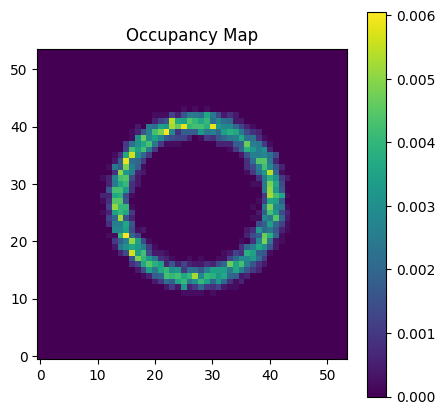

In [3]:
occupancy = compute_occupancy(select_coords, bins=arena_map.shape)
print(occupancy.shape)
# Plot the occupancy 
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
im = ax.imshow(occupancy, origin='lower', cmap='viridis')
fig.colorbar(im, ax=ax)
ax.set_title('Occupancy Map')
plt.show()

In [4]:
aggregator = RatemapAggregator(data['arena_map'], device='cuda')

aggregator.update(select_hs, select_coords)
ratemap = aggregator.get_ratemap().cpu().numpy()
print(ratemap.shape)

(512, 54, 54)


In [15]:
def ratemap_to_angle_profile(ratemaps, nbins=18, radius=None):

    N, X, _ = ratemaps.shape

    yy, xx = np.mgrid[0:X, 0:X]

    cy = X / 2.0
    cx = X / 2.0

    dy = yy - cy
    dx = xx - cx
    angles = np.arctan2(dy, dx)  # [-pi, pi)
    dists  = np.hypot(dy, dx)

    if radius is None:
        radius = np.min([cx, cy, X-1-cx, X-1-cy])
    print(radius)
    
    circle_mask = dists <= radius
    
    edges = np.linspace(-np.pi, np.pi, nbins + 1, endpoint=True)
    bin_centers = 0.5 * (edges[:-1] + edges[1:])

    ang_flat = angles[circle_mask].ravel()
    R_flat = ratemaps[:, circle_mask] 

    ratemap_angle = np.zeros((N, nbins), dtype=float)
    counts = np.histogram(ang_flat, bins=edges)[0]
    for i in range(N):
        
        Ri = R_flat[i]                  
        valid = np.isfinite(Ri)             
        ang_i  = ang_flat[valid]
        R_i    = Ri[valid]
        
        sums = np.histogram(ang_i, bins=edges, weights=R_i)[0]
        ratemap_angle[i] = np.divide(
            sums, counts,
            out=np.zeros_like(sums, dtype=float),
            where=(counts > 0)
        )
    return ratemap_angle, bin_centers, radius

In [16]:
ratemap_angles, angles, radius = ratemap_to_angle_profile(ratemap)

26.0


In [17]:
occupancy_angles, _, _ = ratemap_to_angle_profile(occupancy[None, :, :])

26.0


Computing SIC for neurons: 100%|██████████| 512/512 [00:00<00:00, 26559.36it/s]

Number of place cells: 109 / 512


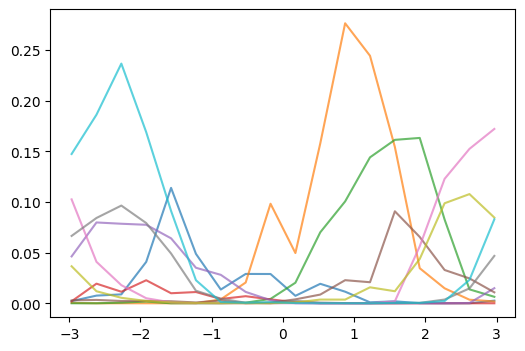

In [19]:
SIC, place_cells = SIC_analysis(ratemap_angles, occupancy_angles, threshold=8)
print(f'Number of place cells: {np.sum(place_cells)} / {num_neuron}')
# Find the place cells index
place_cell_indices = np.where(place_cells)[0]

# Plot the angle profile of place cells
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
for idx in place_cell_indices[10:20]:
    ax.plot(angles, ratemap_angles[idx], alpha=0.7)